This notebook explores the Schotten-Baumann coupling dataset published by Gomes and co-workers (ChemRxiv 2025. DOI: 10.26434/chemrxiv-2025-4tk40).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import colorsys
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors

# Doyle colors
doyle_colors = ["#CE4C6F", "#1561C2", "#188F9D","#C4ADA2","#515798", "#CB7D85", "#A9A9A9"]
# extension of palette with lighter and darker versions
def adjust_lightness(color, factor=1.2):
    """
    Function to make colors lighter (factor > 1) or darker (factor < 1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

lighter = [adjust_lightness(c, 1.2) for c in doyle_colors]
darker  = [adjust_lightness(c, 0.7) for c in doyle_colors]
all_colors = doyle_colors + darker + lighter

# Save the categorical colormap
cat_cmap = ListedColormap(all_colors, name="Doyle_cat")
plt.colormaps.register(cat_cmap)

# Define and save a continuous colormap
colors = [doyle_colors[1],"#FFFFFFD1",doyle_colors[0]]
cont_cmap = LinearSegmentedColormap.from_list("Doyle_cont", colors)
plt.colormaps.register(cont_cmap)

# General plt parameters
plt.rcParams.update({
    "axes.titlesize": 20,        # Subplot title
    "axes.labelsize": 16,        # X and Y labels
    "figure.titlesize": 24,      # Suptitle
    "xtick.labelsize": 14,       # X tick labels
    "ytick.labelsize": 14,       # Y tick labels
    "legend.fontsize": 14,       # Legend text
    "legend.title_fontsize": 14  # Legend titles
})

Load the dataset (taken from https://github.com/gomesgroup/PRISM). The dataset provides different rate labels that either have a bias correction or not. As the bias correction was trained on the obtained rate data, this information would not be available in a prospective experimental scope compaign. Therefore, we decided to use the uncorrected HTE rates instead of the corrected ones.

In [2]:
data = pd.read_csv("SB_raw_data.csv")
print(f"The original dataset has {len(data)} entries.")

# canonicalize SMILES
data["amine_smiles"] = data["amine_smiles"].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))
data["acid_smiles"] = data["acid_smiles"].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))

# prune the data to the columns that are relevant here
data = data[["amine_smiles","acid_smiles","HTE_rate"]]
data.rename(columns={"HTE_rate":"rate"},inplace=True)

data.head()

The original dataset has 1201 entries.


,amine_smiles,acid_smiles,rate
0,CC(C)(C)N,O=C(Cl)c1ccc(F)cc1,521.942558
1,Nc1ccc(F)cc1,O=C(Cl)c1ccc(F)cc1,19.593600
2,COc1ccc(N)cc1,O=C(Cl)c1ccc(F)cc1,425.146340
3,Nc1ccccc1,O=C(Cl)c1ccc(F)cc1,17.876277
4,Cc1cc(C)c(N)c(C)c1,O=C(Cl)c1ccc(F)cc1,16.011251


We can now check how many different reactions were carried out with each reactant in this two-component coupling reaction.

Number of unique amines in the dataset: 54
Most amines were coupled with 31 acid chlorides.


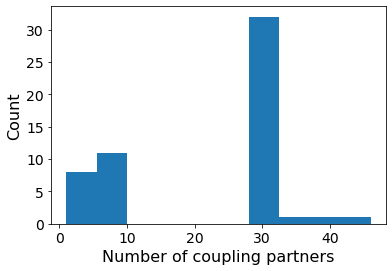

In [3]:
dist_amines = {}
print("Number of unique amines in the dataset:",len(data["amine_smiles"].unique()))
for amine in data["amine_smiles"].unique():
    dist_amines[amine]=(len(data[data["amine_smiles"]==amine]))
counts = list(dist_amines.values())
print(f"Most amines were coupled with {max(set(counts), key=counts.count)} acid chlorides.")

plt.figure()
plt.hist(dist_amines.values())
plt.xlabel("Number of coupling partners")
plt.ylabel("Count")
plt.show()

Number of unique acid chlorides in the dataset: 46
Most acid chlorides were coupled with 35 amines.


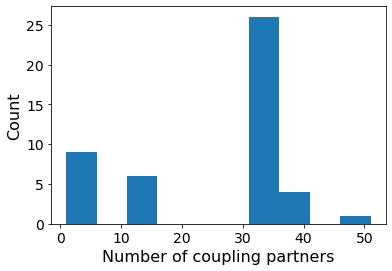

In [4]:
dist_acids = {}
print("Number of unique acid chlorides in the dataset:",len(data["acid_smiles"].unique()))
for acid in data["acid_smiles"].unique():
    dist_acids[acid] = (len(data[data["acid_smiles"]==acid]))
counts = list(dist_acids.values())
print(f"Most acid chlorides were coupled with {max(set(counts), key=counts.count)} amines.")

plt.figure()
plt.hist(dist_acids.values())
plt.xlabel("Number of coupling partners")
plt.ylabel("Count")
plt.show()

An advantage of this dataset is that we can construct a fully combinatorial reaction space with the majority of the samples. Let's prune to such a space.

In [5]:
# remove the coupling partners with few examples from consideration
for acid,count in dist_acids.items():
    if count < 20:
        data = data.loc[data["acid_smiles"] != acid]
for amine,count in dist_amines.items():
    if count < 20:
        data = data.loc[data["amine_smiles"] != amine]
print("Remaining reactions after pruning ",len(data))

Remaining reactions after pruning  1085


1085 reactions is exactly the product of 31*35 (most common number of couplings for the two reaction partners). Let's check if the search space is fully combinatorial now.

In [6]:
dist_acids = {}
for acid in data["acid_smiles"].unique():
    dist_acids[acid] = (len(data[data["acid_smiles"]==acid]))
counts = list(dist_acids.values())
print(f"Unique values for the number of reactions per acid chloride in the pruned search space", set(counts))

dist_amines = {}
for amine in data["amine_smiles"].unique():
    dist_amines[amine] = (len(data[data["amine_smiles"]==amine]))
counts = list(dist_amines.values())
print(f"Unique values for the number of reactions per amine in the pruned search space", set(counts))

Unique values for the number of reactions per acid chloride in the pruned search space {35}
Unique values for the number of reactions per amine in the pruned search space {31}


Now the reaction space is fully combinatorial with 31 acid chlorides and 35 amines! Let's look at the distribution of the reaction rates.

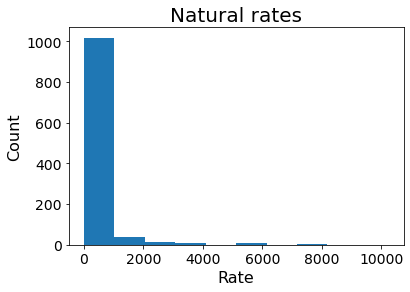

In [7]:
plt.figure()
plt.title("Natural rates")
plt.hist(data["rate"])
plt.xlabel("Rate")
plt.ylabel("Count")
plt.show()

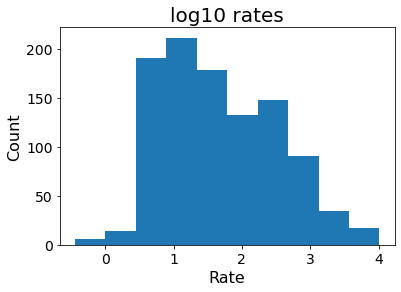

Note: Some rates in the dataset are 0 and were excluded for this analysis as log10(0) = -inf.


In [8]:
plt.figure()
plt.title("log10 rates")
plt.hist(data[data["rate"] > 0]["rate"].apply(lambda x: np.log10(x)))
plt.xlabel("Rate")
plt.ylabel("Count")
plt.show()
print("Note: Some rates in the dataset are 0 and were excluded for this analysis as log10(0) = -inf.")

The reaction rates span a wide range with most rates having a very low value. A log transformation provides a more suitable distribution for machine learning. To enable this transformation, we had to exclude reactants that had reactions with a rate of 0 as this leads to a negative inifinite rate value after the log transformation.

In [9]:
i = 0
for amine in data[data["rate"] == 0]["amine_smiles"].unique():
    data = data.loc[data["amine_smiles"] != amine]
    i += 1
print(f"{i} amines removed from the dataset.")
print("Number of remaining amines:", len(data["amine_smiles"].unique()))
print("")
i = 0
for acid in data[data["rate"] == 0]["acid_smiles"].unique():
    data = data.loc[data["acid_smiles"] != acid]
    i += 1
print(f"{i} acid chlorides removed from the dataset")
print("Number of remaining acid chlorides:", len(data["acid_smiles"].unique()))
print("")

print("Remaining reactions in the dataset:",len(data))


7 amines removed from the dataset.
Number of remaining amines: 28

0 acid chlorides removed from the dataset
Number of remaining acid chlorides: 31

Remaining reactions in the dataset: 868


In [10]:
# log transform the rates
data["rate"] = data["rate"].apply(lambda x: np.log10(x))
data.head()

,amine_smiles,acid_smiles,rate
1,Nc1ccc(F)cc1,O=C(Cl)c1ccc(F)cc1,1.292114
3,Nc1ccccc1,O=C(Cl)c1ccc(F)cc1,1.252277
4,Cc1cc(C)c(N)c(C)c1,O=C(Cl)c1ccc(F)cc1,1.204425
5,CCCCCCCc1ccc(N)cc1,O=C(Cl)c1ccc(F)cc1,1.817767
6,CC(C)c1cccc(C(C)C)c1N,O=C(Cl)c1ccc(F)cc1,1.101844


Save the dataset

In [11]:
data.to_csv("SB_processed_data.csv",index=True,header=True)

Draw the substrates

Amines and their average rate in reaction with the different acid chlorides:


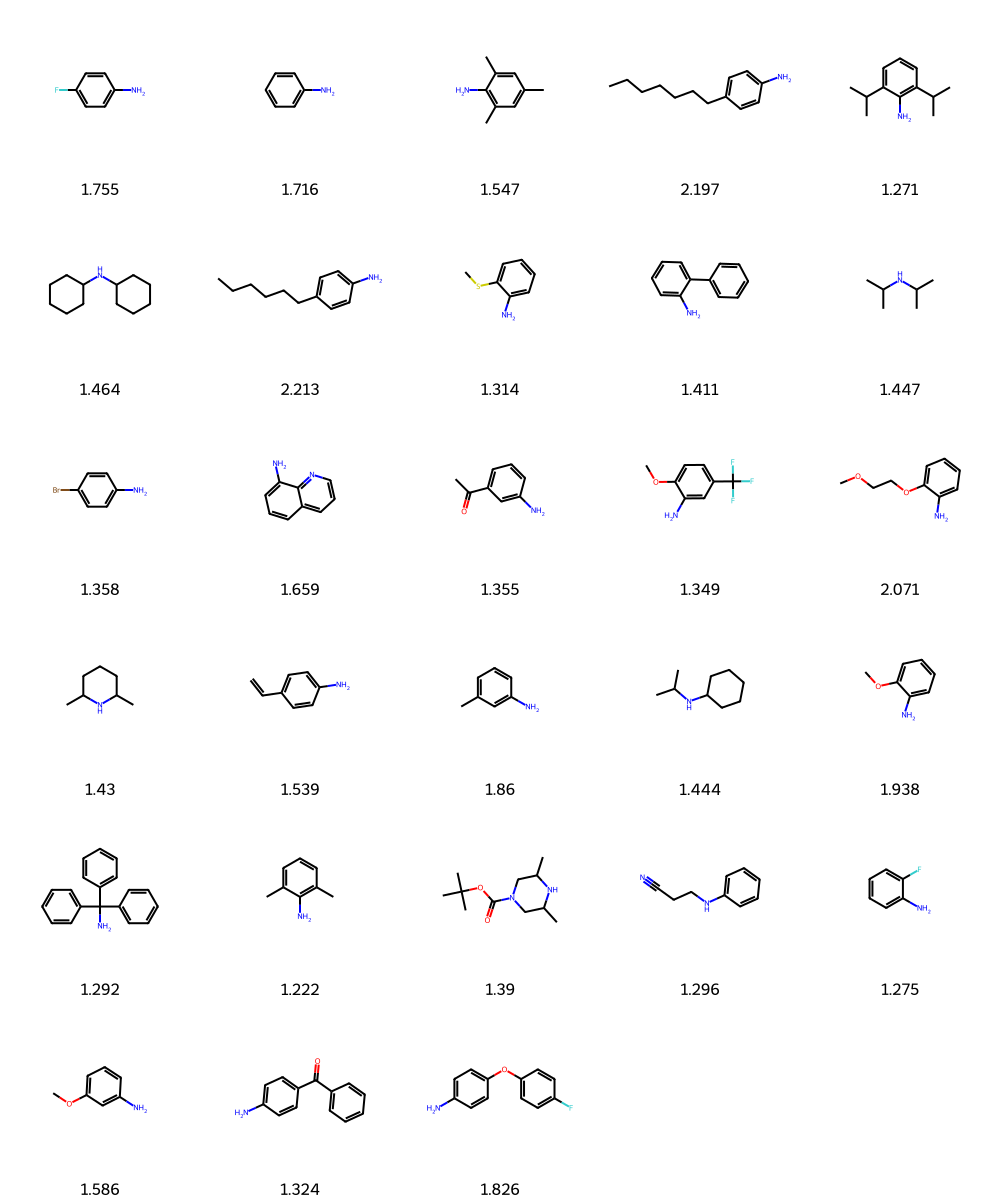




Acid chlorides and their average rate in reaction with the different amines:


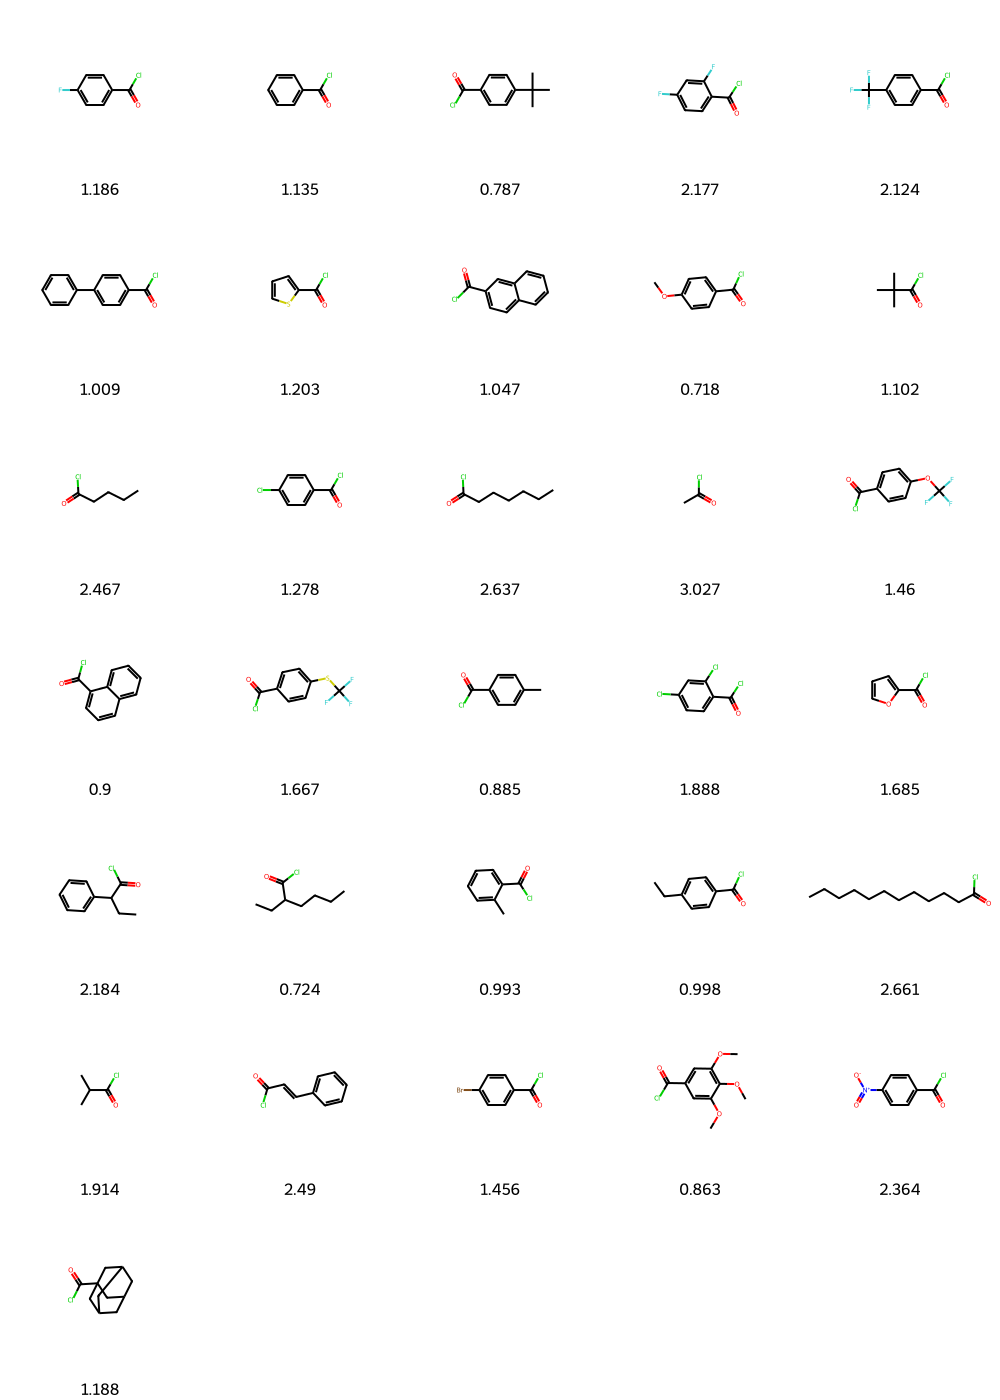

In [21]:
amine_smiles = data["amine_smiles"].unique()
acid_smiles = data["acid_smiles"].unique()
amine_label_dict = {smi: data.loc[data["amine_smiles"] == smi, "rate"].mean() for smi in amine_smiles}
acid_label_dict = {smi: data.loc[data["acid_smiles"] == smi, "rate"].mean() for smi in acid_smiles}

print("Amines and their average rate in reaction with the different acid chlorides:")
display(Draw.MolsToGridImage(mols=[Chem.MolFromSmiles(smi) for smi in amine_smiles],molsPerRow=5, 
                             legends=[str(round(amine_label_dict[smi],3)) for smi in amine_smiles]))
print("\n\n\nAcid chlorides and their average rate in reaction with the different amines:")
display(Draw.MolsToGridImage(mols=[Chem.MolFromSmiles(smi) for smi in acid_smiles],molsPerRow=5, 
                             legends=[str(round(acid_label_dict[smi],3)) for smi in acid_smiles]))